In [1]:

#STEP 1: Load and Clean Data
# Load data
import pandas as pd
df = pd.read_csv('../jk_weather_history_enhanced.csv')

# Remove rows with missing critical data
df = df.dropna(subset=['Temperature (°C)', 'Humidity (%)', 
                        '24h Rain Total (mm)', 'Wind Speed (m/s)'])

# Convert timestamp
df['Fetch_Time_UTC'] = pd.to_datetime(df['Fetch_Time_UTC'])
df = df.sort_values('Fetch_Time_UTC').reset_index(drop=True)

print(f"Total records after cleaning: {len(df)}")
print(f"Date range: {df['Fetch_Time_UTC'].min()} to {df['Fetch_Time_UTC'].max()}")
print(f"Districts covered: {df['District'].nunique()}")


Total records after cleaning: 926
Date range: 2025-09-19 09:17:21 to 2025-11-07 04:16:56
Districts covered: 22


In [2]:
#STEP 2: Create Disaster Risk Labels

# Create RISK LEVELS based on weather severity (not actual disasters)
def calculate_risk_level(row):
    """
    Returns risk level 0-3:
    0 = No Risk
    1 = Low Risk (monitor)
    2 = Medium Risk (prepare)
    3 = High Risk (evacuate)
    """
    risk_score = 0
    
    # === RAINFALL RISK ===
    rain_24h = row['24h Rain Total (mm)']
    rain_current = row['Current Rain (mm/h)']
    
    if rain_24h > 100 or rain_current > 10:  # Extreme
        risk_score += 4
    elif rain_24h > 65 or rain_current > 5:  # Very heavy
        risk_score += 3
    elif rain_24h > 35 or rain_current > 2.5:  # Heavy
        risk_score += 2
    elif rain_24h > 15 or rain_current > 1:  # Moderate
        risk_score += 1
    
    # === WIND RISK ===
    wind = row['Max Wind 24h (m/s)']
    if wind > 20:  # Storm
        risk_score += 3
    elif wind > 15:  # Very strong
        risk_score += 2
    elif wind > 10:  # Strong
        risk_score += 1
    
    # === HUMIDITY + RAIN = LANDSLIDE RISK ===
    humidity = row['Humidity (%)']
    if humidity > 85 and rain_24h > 30:
        risk_score += 2
    elif humidity > 75 and rain_24h > 20:
        risk_score += 1
    
    # === PRESSURE DROP = STORM COMING ===
    pressure = row['Pressure (hPa)']
    if pressure < 990:  # Very low
        risk_score += 2
    elif pressure < 1005:  # Low
        risk_score += 1
    
    # === TEMPERATURE EXTREMES ===
    temp = row['Temperature (°C)']
    if temp > 40:  # Heatwave
        risk_score += 2
    elif temp < 0:  # Freezing
        risk_score += 1
    
    # Convert score to risk level
    if risk_score >= 6:
        return 3  # HIGH RISK
    elif risk_score >= 4:
        return 2  # MEDIUM RISK
    elif risk_score >= 2:
        return 1  # LOW RISK
    else:
        return 0  # NO RISK

# Apply function
df['risk_level'] = df.apply(calculate_risk_level, axis=1)

# Check distribution
print("=== RISK LEVEL DISTRIBUTION ===")
print(df['risk_level'].value_counts().sort_index())
print("\nPercentages:")
print(df['risk_level'].value_counts(normalize=True).sort_index() * 100)

# Show examples of each level
for level in range(4):
    print(f"\n=== RISK LEVEL {level} EXAMPLES ===")
    cols = ['District', '24h Rain Total (mm)', 'Current Rain (mm/h)', 
            'Max Wind 24h (m/s)', 'Humidity (%)', 'risk_level']
    print(df[df['risk_level']==level][cols].head(3))

=== RISK LEVEL DISTRIBUTION ===
risk_level
0    767
1    158
2      1
Name: count, dtype: int64

Percentages:
risk_level
0    82.829374
1    17.062635
2     0.107991
Name: proportion, dtype: float64

=== RISK LEVEL 0 EXAMPLES ===
  District  24h Rain Total (mm)  Current Rain (mm/h)  Max Wind 24h (m/s)  \
2    Jammu                  5.1                 0.94                 6.6   
3    Samba                  0.8                 0.55                 6.0   
4   Kathua                  8.5                 1.69                 6.0   

   Humidity (%)  risk_level  
2          44.0           0  
3          69.0           0  
4          69.0           0  

=== RISK LEVEL 1 EXAMPLES ===
   District  24h Rain Total (mm)  Current Rain (mm/h)  Max Wind 24h (m/s)  \
1     Samba                  0.0                 1.16                 1.3   
68    Jammu                  0.0                 0.00                 1.8   
69    Samba                  0.0                 0.00                 1.9   

    H

In [3]:
#STEP 3: Feature Engineering
# Time-based features
df['hour'] = df['Fetch_Time_UTC'].dt.hour
df['day'] = df['Fetch_Time_UTC'].dt.day
df['month'] = df['Fetch_Time_UTC'].dt.month
df['day_of_week'] = df['Fetch_Time_UTC'].dt.dayofweek

# Sort by district and time for rolling features
df = df.sort_values(['District', 'Fetch_Time_UTC'])

# Create rolling features per district
df['rainfall_3h_avg'] = df.groupby('District')['24h Rain Total (mm)'].rolling(window=3, min_periods=1).mean().reset_index(0, drop=True)
df['temp_3h_avg'] = df.groupby('District')['Temperature (°C)'].rolling(window=3, min_periods=1).mean().reset_index(0, drop=True)
df['humidity_3h_avg'] = df.groupby('District')['Humidity (%)'].rolling(window=3, min_periods=1).mean().reset_index(0, drop=True)

# Rain intensity change
df['rain_change'] = df.groupby('District')['24h Rain Total (mm)'].diff().fillna(0)

print("\nFeatures created successfully!")
print(df[['District', 'risk_level', 'rainfall_3h_avg', 'rain_change']].head(10))

#print(df[['District', 'disaster_risk', 'rainfall_3h_avg', 'rain_change']].head(10))


Features created successfully!
     District  risk_level  rainfall_3h_avg  rain_change
15   Anantnag           0         7.600000          0.0
37   Anantnag           0         7.250000         -0.7
59   Anantnag           0         7.833333          2.1
81   Anantnag           0         8.500000          0.6
103  Anantnag           0         6.900000         -7.5
125  Anantnag           0         4.333333         -0.8
147  Anantnag           0         2.333333          2.3
169  Anantnag           0         1.666667         -3.5
191  Anantnag           0         3.433333          6.5
213  Anantnag           0         3.633333         -2.4


In [4]:
# ---STEP 4: Prepare Features for ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode districts
le = LabelEncoder()
df['district_encoded'] = le.fit_transform(df['District'])

# Features
feature_cols = [
    'Temperature (°C)', 
    'Humidity (%)', 
    'Wind Speed (m/s)',
    'Max Wind 24h (m/s)', 
    'Pressure (hPa)', 
    'Current Rain (mm/h)',
    '24h Rain Total (mm)', 
    'Dew Point (°C)',
    'rainfall_3h_avg',
    'temp_3h_avg',
    'humidity_3h_avg',
    'rain_change',
    'hour', 
    'month',
    'district_encoded'
]

X = df[feature_cols]
y = df['risk_level']

# Check class distribution
print("=== CLASS DISTRIBUTION ===")
print(y.value_counts().sort_index())

# Split WITHOUT stratify (too few samples in class 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Training samples: {len(X_train)}")
print(f"✅ Testing samples: {len(X_test)}")
print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())
print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

=== CLASS DISTRIBUTION ===
risk_level
0    318
1     79
2      1
Name: count, dtype: int64

✅ Training samples: 318
✅ Testing samples: 80

Training class distribution:
risk_level
0    258
1     59
2      1
Name: count, dtype: int64

Testing class distribution:
risk_level
0    60
1    20
Name: count, dtype: int64


In [5]:
# --- STEP 5: Train Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Train model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',  # Important for imbalanced data
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)

# Find which classes the model learned
classes_present = rf_model.classes_
print(f"Classes model learned: {classes_present}")

# Evaluation
print("\n=== MODEL PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Create labels for only the classes that exist
target_names = [f'Risk Level {i}' for i in classes_present]

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, labels=classes_present, 
                           target_names=target_names, zero_division=0))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred, labels=classes_present)
print(cm)

# Show per-class accuracy
print("\n=== PER-CLASS PERFORMANCE ===")
for i, class_label in enumerate(classes_present):
    class_mask = (y_test == class_label)
    if class_mask.sum() > 0:
        class_acc = (y_pred[class_mask] == class_label).mean()
        print(f"Risk Level {class_label}: {class_acc:.2%} ({class_mask.sum()} samples)")

Classes model learned: [0 1 2]

=== MODEL PERFORMANCE ===
Accuracy: 1.000

Classification Report:
              precision    recall  f1-score   support

Risk Level 0       1.00      1.00      1.00        60
Risk Level 1       1.00      1.00      1.00        20
Risk Level 2       0.00      0.00      0.00         0

    accuracy                           1.00        80
   macro avg       0.67      0.67      0.67        80
weighted avg       1.00      1.00      1.00        80


Confusion Matrix:
[[60  0  0]
 [ 0 20  0]
 [ 0  0  0]]

=== PER-CLASS PERFORMANCE ===
Risk Level 0: 100.00% (60 samples)
Risk Level 1: 100.00% (20 samples)



=== TOP 10 IMPORTANT FEATURES ===
                feature  importance
4        Pressure (hPa)    0.229495
6   24h Rain Total (mm)    0.205160
5   Current Rain (mm/h)    0.139860
3    Max Wind 24h (m/s)    0.068675
8       rainfall_3h_avg    0.067183
2      Wind Speed (m/s)    0.064730
0      Temperature (°C)    0.063992
7        Dew Point (°C)    0.049379
9           temp_3h_avg    0.043431
11          rain_change    0.028558

✅ Plot saved as 'feature_importance.png'


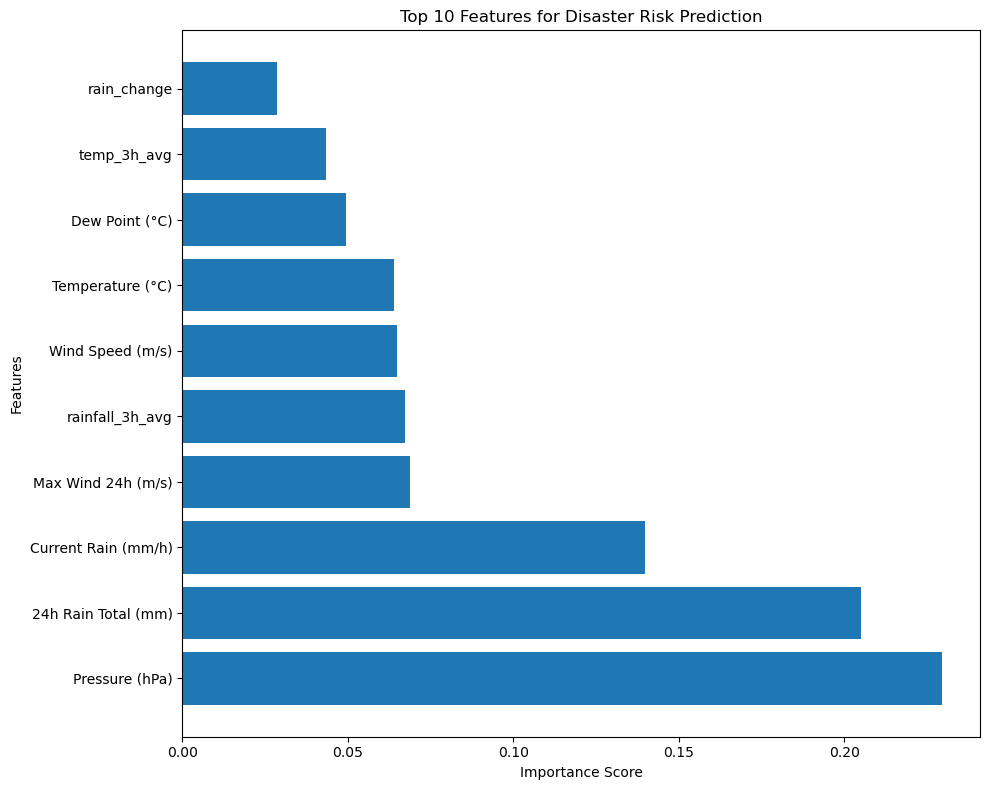

In [7]:
#STEP 6: Feature Importance
import matplotlib.pyplot as plt

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== TOP 10 IMPORTANT FEATURES ===")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 8))
top_10 = feature_importance.head(10)
plt.barh(top_10['feature'], top_10['importance'])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Features for Disaster Risk Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
print("\n✅ Plot saved as 'feature_importance.png'")
plt.show()


In [7]:
#STEP 7: Save Model & Components
import joblib

# Save all components
joblib.dump(rf_model, 'disaster_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'district_encoder.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')

print("\n✅ MODEL SAVED SUCCESSFULLY!")
print("\nFiles created:")
print("  ✓ disaster_prediction_model.pkl")
print("  ✓ scaler.pkl")
print("  ✓ district_encoder.pkl")
print("  ✓ feature_columns.pkl")


✅ MODEL SAVED SUCCESSFULLY!

Files created:
  ✓ disaster_prediction_model.pkl
  ✓ scaler.pkl
  ✓ district_encoder.pkl
  ✓ feature_columns.pkl


In [8]:
#STEP 8: Create Prediction Function
import joblib
import pandas as pd
import numpy as np

# Load components
model = joblib.load('disaster_prediction_model.pkl')
scaler = joblib.load('scaler.pkl')
district_encoder = joblib.load('district_encoder.pkl')
feature_cols = joblib.load('feature_columns.pkl')

def predict_disaster_risk(weather_data, district_name):
    """
    Predict disaster risk for given weather conditions
    
    Parameters:
    -----------
    weather_data : dict
        Dictionary with weather parameters:
        - Temperature (°C)
        - Humidity (%)
        - Wind Speed (m/s)
        - Max Wind 24h (m/s)
        - Pressure (hPa)
        - Current Rain (mm/h)
        - 24h Rain Total (mm)
        - Dew Point (°C)
    
    district_name : str
        Name of district (e.g., 'Jammu', 'Srinagar')
    
    Returns:
    --------
    dict with risk_level, risk_name, and probabilities
    """
    
    # Encode district
    try:
        district_code = district_encoder.transform([district_name])[0]
    except:
        print(f"⚠️ District '{district_name}' not found. Using default.")
        district_code = 0
    
    # Prepare input
    input_data = {
        'Temperature (°C)': weather_data.get('temperature', 25),
        'Humidity (%)': weather_data.get('humidity', 60),
        'Wind Speed (m/s)': weather_data.get('wind_speed', 2),
        'Max Wind 24h (m/s)': weather_data.get('max_wind_24h', 4),
        'Pressure (hPa)': weather_data.get('pressure', 1013),
        'Current Rain (mm/h)': weather_data.get('current_rain', 0),
        '24h Rain Total (mm)': weather_data.get('rain_24h', 0),
        'Dew Point (°C)': weather_data.get('dew_point', 15),
        'rainfall_3h_avg': weather_data.get('rainfall_3h_avg', 0),
        'temp_3h_avg': weather_data.get('temp_3h_avg', 25),
        'humidity_3h_avg': weather_data.get('humidity_3h_avg', 60),
        'rain_change': weather_data.get('rain_change', 0),
        'hour': weather_data.get('hour', 12),
        'month': weather_data.get('month', 7),
        'district_encoded': district_code
    }
    
    # Create DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Scale
    input_scaled = scaler.transform(input_df[feature_cols])
    
    # Predict
    risk_level = model.predict(input_scaled)[0]
    probabilities = model.predict_proba(input_scaled)[0]
    
    # Risk names
    risk_names = {
        0: "NO RISK - Safe Conditions",
        1: "LOW RISK - Monitor Weather",
        2: "MEDIUM RISK - Prepare Resources",
        3: "HIGH RISK - Evacuate if Needed"
    }
    
    result = {
        'district': district_name,
        'risk_level': int(risk_level),
        'risk_name': risk_names.get(risk_level, "UNKNOWN"),
        'probabilities': {
            'no_risk': f"{probabilities[0]*100:.1f}%",
            'low_risk': f"{probabilities[1]*100:.1f}%" if len(probabilities) > 1 else "0%",
            'medium_risk': f"{probabilities[2]*100:.1f}%" if len(probabilities) > 2 else "0%",
            'high_risk': f"{probabilities[3]*100:.1f}%" if len(probabilities) > 3 else "0%"
        }
    }
    
    return result

# Test with current safe weather
print("=== TEST 1: NORMAL WEATHER ===")
normal_weather = {
    'temperature': 24,
    'humidity': 55,
    'wind_speed': 2.5,
    'max_wind_24h': 4,
    'pressure': 1015,
    'current_rain': 0.5,
    'rain_24h': 8,
    'dew_point': 15,
    'rainfall_3h_avg': 7,
    'temp_3h_avg': 24,
    'humidity_3h_avg': 56,
    'rain_change': 1,
    'hour': 14,
    'month': 7
}
result1 = predict_disaster_risk(normal_weather, 'Srinagar')
print(f"District: {result1['district']}")
print(f"Risk Level: {result1['risk_level']} - {result1['risk_name']}")
print(f"Probabilities: {result1['probabilities']}")

# Test with EXTREME weather (disaster scenario)
print("\n=== TEST 2: EXTREME WEATHER (DISASTER) ===")
extreme_weather = {
    'temperature': 28,
    'humidity': 92,
    'wind_speed': 8,
    'max_wind_24h': 22,  # Storm
    'pressure': 988,  # Very low
    'current_rain': 15,  # Extreme
    'rain_24h': 150,  # Flood level
    'dew_point': 24,
    'rainfall_3h_avg': 120,
    'temp_3h_avg': 27,
    'humidity_3h_avg': 90,
    'rain_change': 60,
    'hour': 3,
    'month': 8
}
result2 = predict_disaster_risk(extreme_weather, 'Jammu')
print(f"District: {result2['district']}")
print(f"Risk Level: {result2['risk_level']} - {result2['risk_name']}")
print(f"Probabilities: {result2['probabilities']}")

# Test with heavy rain
print("\n=== TEST 3: HEAVY RAIN ===")
heavy_rain = {
    'temperature': 26,
    'humidity': 85,
    'wind_speed': 4,
    'max_wind_24h': 8,
    'pressure': 1005,
    'current_rain': 8,
    'rain_24h': 75,
    'dew_point': 20,
    'rainfall_3h_avg': 65,
    'temp_3h_avg': 25,
    'humidity_3h_avg': 82,
    'rain_change': 25,
    'hour': 20,
    'month': 8
}
result3 = predict_disaster_risk(heavy_rain, 'Anantnag')
print(f"District: {result3['district']}")
print(f"Risk Level: {result3['risk_level']} - {result3['risk_name']}")
print(f"Probabilities: {result3['probabilities']}")

=== TEST 1: NORMAL WEATHER ===
District: Srinagar
Risk Level: 0 - NO RISK - Safe Conditions
Probabilities: {'no_risk': '100.0%', 'low_risk': '0.0%', 'medium_risk': '0.0%', 'high_risk': '0%'}

=== TEST 2: EXTREME WEATHER (DISASTER) ===
District: Jammu
Risk Level: 0 - NO RISK - Safe Conditions
Probabilities: {'no_risk': '42.5%', 'low_risk': '17.0%', 'medium_risk': '40.5%', 'high_risk': '0%'}

=== TEST 3: HEAVY RAIN ===
District: Anantnag
Risk Level: 0 - NO RISK - Safe Conditions
Probabilities: {'no_risk': '68.5%', 'low_risk': '0.0%', 'medium_risk': '31.5%', 'high_risk': '0%'}
